# Activity & Origins — FIFA World Cup 2026 (Toronto & Vancouver)

**Two questions:**
1. **How much activity is there** around the two host cities during the World Cup, relative to prior periods?
2. **Where is that activity coming from** — how far do the people showing up actually travel?

This notebook builds on the intuition from `explore_daily_activity.ipynb` (same style: imports → constants → sectioned exploration), but uses different, more targeted inputs:

- **Daily activity** — `data/match-activity/daily_final_just_num.xlsx`. One sheet per `{city}_{geometry}`, columns `DATE`, `UNIQUESTOPS`, `GEOMETRYLEVEL`, `denom_for_geom_lvl`, `normed_devices`. Unlike the earlier notebooks, `normed_devices` here is **not** a device-panel-size adjustment — it's literally `UNIQUESTOPS / sum(UNIQUESTOPS over the whole file for that geometry)`, i.e. each day's *share of total footfall* across the whole ~14-month window. We verify this definition empirically below before relying on it.
- **Home origins** — `data/match-activity/origin_by_region_just_num_rings.xlsx`. One sheet per `{city}_{geometry}`, with one row per match day per home `REGION`, giving `HomeDevices` (raw) and `AdjHomeDevices` (scaled for day-of-week/denominator drift via `ScaleFactor`), plus two pre-computed percentage columns (`WithinGTHAPct`/`WithinMetroVanPct` and `NAWidePct`) that we'll validate rather than trust blindly.
- **Boundary geometries** — `data/final_geoms/` (Statistics Canada CSD/CMA/province shapefiles) give us real polygons for every home region, so the proportional symbol maps use actual geometry-derived centroids instead of hand-picked coordinates.
- **Scope**: only the `csd`, `merged_2km`, and `merged_5km` geometries — the other buffer rings from earlier explorations (100m–1km, 10km) simply aren't present in these files and that's expected, not missing data.
- Every other file under `data/match-activity/` is reference-only for this notebook (prior explorations) — we don't load or re-examine them here.

**Time periods** (detected empirically from the actual dates present, not assumed):
- **2025 benchmark** — June 2025 (30 days), a same-calendar-month prior-year baseline.
- **Pre-2026** — 2026-04-22 to 2026-05-31 (~40 days), the run-up immediately before the tournament window.
- **Main 2026** — 2026-06-01 to 2026-07-10 (~40 days), the tournament window itself, containing all match days.

**Match days** include every date present in the origin file, which turned out to include a couple of dates beyond the original group-stage list (later-round matches): Toronto adds 2026-07-02, Vancouver adds 2026-07-02 and 2026-07-07.

**A data quality issue we found and correct for**: in the origin file, `NAWidePct` for every "minor" region (small provinces, US) is **not** an individual share — every minor region on a given date shares one identical repeated value equal to the *entire* leftover residual after the metro-CMA and provincial-remainder shares. We demonstrate this below and recompute clean, individually-correct percentages directly from `AdjHomeDevices` for both percentage columns, rather than trust the pre-computed ones.

No outputs are saved in this notebook — it's purely exploratory, to build a narrative around World Cup activity and visitor origins.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from tqdm.notebook import tqdm

pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.dpi"] = 110


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
ACTIVITY_PATH = "../../data/match-activity/daily_final_just_num.xlsx"
ORIGIN_PATH = "../../data/match-activity/origin_by_region_just_num_rings.xlsx"
GEOMS_DIR = "../../data/final_geoms"

CITIES = ["toronto", "vancouver"]

# Geometry levels used in this notebook, ordered by physical scale.
# (100m-1km and 10km rings from earlier explorations aren't present in these files - expected, not missing.)
LEVEL_ORDER = ["merged_2km", "merged_5km", "csd"]

# Two activity metrics: raw unique stops, and each day's share of total footfall over the whole file
METRICS = [
    ("UNIQUESTOPS", "Unique stops (raw)"),
    ("normed_devices", "Share of total footfall (normalized)"),
]

# Time periods (dates as they actually appear in daily_final_just_num.xlsx - verified, not assumed)
BENCHMARK_2025 = ("2025-06-01", "2025-06-30")
PRE_2026 = ("2026-04-22", "2026-05-31")
MAIN_2026 = ("2026-06-01", "2026-07-10")

PERIOD_WINDOWS = [
    ("2025 benchmark (Jun '25)", BENCHMARK_2025, "steelblue"),
    ("Pre-2026 (Apr 22 - May 31 '26)", PRE_2026, "darkorange"),
    ("Main 2026 (Jun 1 - Jul 10 '26)", MAIN_2026, "crimson"),
]

# FIFA World Cup 2026 match days per host city, within MAIN_2026.
# Includes later-round dates (2026-07-02, 2026-07-07) found in the origin file beyond the original group-stage list.
MATCH_DAYS = {
    "toronto": pd.to_datetime(["2026-06-12", "2026-06-17", "2026-06-20", "2026-06-23", "2026-06-26", "2026-07-02"]),
    "vancouver": pd.to_datetime(["2026-06-13", "2026-06-18", "2026-06-21", "2026-06-24", "2026-06-26",
                                  "2026-07-02", "2026-07-07"]),
}

# The four origin sources used for the maps & origin trend lines (per city, csd + merged_2km only - not 5km)
MAP_SOURCES = ["toronto_csd", "toronto_merged_2km", "vancouver_csd", "vancouver_merged_2km"]

# --- Geometry sources for the proportional symbol maps (data/final_geoms) ---
# CSD (municipality) polygons for the two metro regions. CSDNAME "Toronto"/"Vancouver" corresponds to
# the origin file's "Toronto CSD"/"Vancouver CSD" region, so we rename those two on load.
CSD_SHAPEFILES = {
    "toronto": f"{GEOMS_DIR}/csd_gtha/csds_metro_gtha.shp",
    "vancouver": f"{GEOMS_DIR}/csd_vancouver/csds_metro_van.shp",
}
CSD_NAME_TO_REGION = {"Toronto": "Toronto CSD", "Vancouver": "Vancouver CSD"}

# CMA (metro) boundary - single polygon per city. (The GTHA file's CMANAME attribute misleadingly reads
# "Hamilton", but the geometry itself is the full ~8,000 km2 combined Toronto-Hamilton CMA - confirmed by area/bounds.)
CMA_SHAPEFILES = {
    "toronto": f"{GEOMS_DIR}/cma_gtha/toronto_hamilton_cma.shp",
    "vancouver": f"{GEOMS_DIR}/cma_vancouver/vancouver_cma.shp",
}
CMA_REGION_NAME = {"toronto": "Toronto Hamilton CMA", "vancouver": "Vancouver CMA"}
REST_OF_PROVINCE_REGION_NAME = {"toronto": "Ontario - GTHA", "vancouver": "BC - Metro Van"}
HOME_PROVINCE = {"toronto": "Ontario", "vancouver": "British Columbia"}

# Province/territory boundary files, for every province/territory REGION appearing in the origin file
PROVINCE_SHAPEFILES = {
    "Ontario": "on", "British Columbia": "bc", "Alberta": "ab", "Manitoba": "mb", "Saskatchewan": "sk",
    "Quebec": "qb", "Nova Scotia": "ns", "New Brunswick": "nb", "Newfoundland and Labrador": "nl",
    "Prince Edward Island": "pe", "Yukon": "yk", "Northwest Territories": "nt", "Nunavut": "nu",
}

# No Canadian boundary file covers the US as a whole - approximate center of the contiguous US, used as-is.
US_COORD = (39.8, -98.6)

CITY_CENTER = {"toronto": (43.70, -79.42), "vancouver": (49.28, -123.12)}


## 1. Load & assemble the daily activity data

`daily_final_just_num.xlsx` has one sheet per `{city}_{geometry}` rather than one long table, so we read every sheet and stack them, deriving `city` and `level` from the sheet name. We also confirm empirically that `normed_devices` really is each day's share of that geometry's total footfall — i.e. `denom_for_geom_lvl` is a single constant per sheet equal to `sum(UNIQUESTOPS)` over the whole file, not a daily device-panel count like in earlier notebooks.


In [3]:
xl = pd.ExcelFile(ACTIVITY_PATH)
frames = []
for sheet in tqdm(xl.sheet_names, desc="activity sheets"):
    city, level = sheet.split("_", 1)
    if level not in LEVEL_ORDER:
        continue  # e.g. toronto_merged_10km - out of scope for this notebook
    d = xl.parse(sheet)
    d["city"], d["level"] = city, level
    frames.append(d)

activity = pd.concat(frames, ignore_index=True)
activity["DATE"] = pd.to_datetime(activity["DATE"], format="%Y%m%d")

assert (activity["GEOMETRYLEVEL"] == activity["city"] + "_" + activity["level"]).all()
assert not activity.duplicated(subset=["DATE", "GEOMETRYLEVEL"]).any()

# Confirm normed_devices really is UNIQUESTOPS / sum(UNIQUESTOPS-over-the-whole-file), per geometry
denom_matches_total = activity.groupby("GEOMETRYLEVEL", group_keys=False).apply(
    lambda g: np.isclose(g["denom_for_geom_lvl"].iloc[0], g["UNIQUESTOPS"].sum()), include_groups=False
)
print("denom_for_geom_lvl == sum(UNIQUESTOPS) for every geometry:", bool(denom_matches_total.all()))
print("max |normed_devices - UNIQUESTOPS/denom|:",
      (activity["normed_devices"] - activity["UNIQUESTOPS"] / activity["denom_for_geom_lvl"]).abs().max())

print("\nCities x levels:", sorted(activity["city"].unique()), "x", LEVEL_ORDER)
print("Date range:", activity["DATE"].min().date(), "to", activity["DATE"].max().date())

print("\nRow counts per city/level within each period (sanity check - should equal the period length exactly):")
for label, window, _ in PERIOD_WINDOWS:
    start, end = pd.to_datetime(window[0]), pd.to_datetime(window[1])
    expected = (end - start).days + 1
    counts = activity[(activity["DATE"] >= start) & (activity["DATE"] <= end)].groupby(["city", "level"]).size()
    ok = (counts == expected).all()
    print(f"  {label}: expected {expected} days/geometry -> {'all match' if ok else 'MISMATCH: ' + str(counts.to_dict())}")

activity.groupby(["city", "level"])["UNIQUESTOPS"].describe().reindex(LEVEL_ORDER, level="level")


activity sheets:   0%|          | 0/7 [00:00<?, ?it/s]

denom_for_geom_lvl == sum(UNIQUESTOPS) for every geometry: True
max |normed_devices - UNIQUESTOPS/denom|: 5.0306980803327406e-17

Cities x levels: ['toronto', 'vancouver'] x ['merged_2km', 'merged_5km', 'csd']
Date range: 2025-06-01 to 2026-07-10

Row counts per city/level within each period (sanity check - should equal the period length exactly):
  2025 benchmark (Jun '25): expected 30 days/geometry -> all match
  Pre-2026 (Apr 22 - May 31 '26): expected 40 days/geometry -> all match
  Main 2026 (Jun 1 - Jul 10 '26): expected 40 days/geometry -> all match


count         mean         std          min  \
city      level                                                       
toronto   merged_2km 110.0000  20,490.2455  3,914.9123  11,555.0000   
          merged_5km 110.0000  98,748.5545 20,351.3454  54,900.0000   
          csd        110.0000 271,267.8545 41,234.1250 178,437.0000   
vancouver merged_2km 110.0000  21,497.8000  3,953.4326  10,849.0000   
          merged_5km 110.0000  58,609.2545  9,183.1049  29,530.0000   
          csd        110.0000  62,167.5636  9,562.6153  32,269.0000   

                              25%          50%          75%          max  
city      level                                                           
toronto   merged_2km  18,069.5000  20,344.5000  22,757.5000  30,319.0000  
          merged_5km  81,325.0000  99,375.0000 111,477.7500 146,763.0000  
          csd        245,119.2500 266,671.5000 307,369.2500 368,011.0000  
vancouver merged_2km  18,312.7500  21,653.0000  25,153.7500  29,114.0000  
          merged_5km  52,635.5000  59,009.0000  66,187.2500  76,008.0000  
          csd         55,473.7500  62,479.5000  69,631.5000  80,970.0000

## 2. Load & assemble the origin data

Same stacking approach as above. Each sheet holds, per match day, a nested breakdown of where devices seen at the venue geometry call "home":
- A **metro-level breakdown** (`WithinGTHAPct` for Toronto, `WithinMetroVanPct` for Vancouver): an exhaustive split of the CSD + every surrounding municipality, summing to 100%.
- An **NA-wide breakdown** (`NAWidePct`): the home CMA, the rest of the home province (`Ontario - GTHA` / `BC - Metro Van`), other provinces, and the US.
- A couple of parent/context rows (e.g. `Ontario`, `British Columbia` in their own city's sheet) that are just raw totals, not part of either percentage breakdown.


In [4]:
xl_o = pd.ExcelFile(ORIGIN_PATH)
frames = []
for sheet in tqdm(xl_o.sheet_names, desc="origin sheets"):
    city, level = sheet.split("_", 1)
    d = xl_o.parse(sheet)
    d["city"], d["level"], d["source"] = city, level, sheet
    frames.append(d)

origin = pd.concat(frames, ignore_index=True)
origin["DATE"] = pd.to_datetime(origin["DATE"], format="%Y%m%d")

print("Sources:", sorted(origin["source"].unique()))
print("Unique regions across all sources:", origin["REGION"].nunique())
print("\nMatch dates present per city:")
for city in CITIES:
    print(f"  {city}:", sorted(d.date().isoformat() for d in origin.loc[origin["city"] == city, "DATE"].unique()))

origin[["source", "REGION", "HomeDevices", "AdjHomeDevices", "WithinGTHAPct", "WithinMetroVanPct", "NAWidePct"]].sample(5, random_state=0)


origin sheets:   0%|          | 0/6 [00:00<?, ?it/s]

Sources: ['toronto_csd', 'toronto_merged_2km', 'toronto_merged_5km', 'vancouver_csd', 'vancouver_merged_2km', 'vancouver_merged_5km']
Unique regions across all sources: 70

Match dates present per city:
  toronto: ['2026-06-12', '2026-06-17', '2026-06-20', '2026-06-23', '2026-06-26', '2026-07-02']
  vancouver: ['2026-06-13', '2026-06-18', '2026-06-21', '2026-06-24', '2026-06-26', '2026-07-02', '2026-07-07']


,source,REGION,HomeDevices,AdjHomeDevices,WithinGTHAPct,WithinMetroVanPct,NAWidePct
326,toronto_merged_2km,Mississauga,400,279.5898,0.0230,NaN,NaN
933,vancouver_csd,Maple Ridge,179,142.9446,NaN,0.0040,NaN
279,toronto_merged_2km,King,7,4.6073,0.0004,NaN,NaN
1261,vancouver_merged_5km,Pitt Meadows,41,24.7858,NaN,0.0008,NaN
1435,vancouver_merged_5km,BC - Metro Van,2572,"2,231.9141",NaN,NaN,0.0588


### 2a. The `NAWidePct` bug

Looking at one match day's `toronto_csd` breakdown: `WithinGTHAPct` sums to 1 across the municipality-level rows as expected. But `NAWidePct` is only genuinely distinct for the CMA and provincial-remainder rows — every smaller province and the US on that *same date* share one **identical** value, and that value equals the entire leftover residual (`1 - CMA_share - remainder_share`), not each region's own slice. We confirm this holds across every date/source, then recompute both percentage columns ourselves directly from `AdjHomeDevices` (which is trustworthy at every level) so the minor-region shares are individually correct.


In [5]:
sample = origin[(origin["source"] == "toronto_csd") & (origin["DATE"] == "2026-06-12")].sort_values("HomeDevices", ascending=False)
print(sample[["REGION", "HomeDevices", "WithinGTHAPct", "NAWidePct"]].head(12).to_string(index=False))

vc = sample["NAWidePct"].value_counts()
repeated = vc[vc > 1]
print(f"\nOn this single date, {int(repeated.sum())} different regions share the identical NAWidePct value {repeated.index[0]:.6f}")
print("even though their HomeDevices counts differ wildly -> confirms it's a broadcast residual, not a real share.")

# confirm this holds on every date, across every source
bug_counts = origin.groupby(["source", "DATE"])["NAWidePct"].apply(lambda s: (s.value_counts() > 1).sum())
print(f"\nDates/sources with at least one repeated NAWidePct value: {(bug_counts > 0).sum()} / {len(bug_counts)}")

# --- Recompute both percentage columns ourselves from AdjHomeDevices ---
origin["metro_pct_orig"] = origin["WithinGTHAPct"].combine_first(origin["WithinMetroVanPct"])

def recompute_share(df, membership_col, new_col):
    in_group = df[membership_col].notna()
    totals = df.loc[in_group].groupby(["source", "DATE"])["AdjHomeDevices"].transform("sum")
    df[new_col] = np.nan
    df.loc[in_group, new_col] = df.loc[in_group, "AdjHomeDevices"] / totals
    return df

origin = recompute_share(origin, "metro_pct_orig", "metro_pct")
origin = recompute_share(origin, "NAWidePct", "na_pct")

print("\nRecomputed group sums (should be ~1.0 for every source/date):")
for col in ["metro_pct", "na_pct"]:
    sums = origin.groupby(["source", "DATE"])[col].sum(min_count=1).dropna()
    print(f"  {col}: min={sums.min():.6f}, max={sums.max():.6f}")

print("\nSame sample date, recomputed na_pct (now each minor region gets its own share):")
sample2 = origin[(origin["source"] == "toronto_csd") & (origin["DATE"] == "2026-06-12")].sort_values("HomeDevices", ascending=False)
print(sample2[["REGION", "HomeDevices", "NAWidePct", "na_pct"]].head(12).to_string(index=False))


              REGION  HomeDevices  WithinGTHAPct  NAWidePct
             Ontario       223935            NaN        NaN
Toronto Hamilton CMA       212370            NaN     0.9260
         Toronto CSD       190566         0.9094        NaN
      Ontario - GTHA        10558            NaN     0.0463
         Mississauga         4328         0.0183        NaN
             Vaughan         3268         0.0136        NaN
            Brampton         3175         0.0134        NaN
                  US         3132            NaN     0.0278
             Markham         2762         0.0109        NaN
       Richmond Hill         1464         0.0060        NaN
            Hamilton         1067         0.0049        NaN
                Ajax          887         0.0037        NaN

On this single date, 12 different regions share the identical NAWidePct value 0.027782
even though their HomeDevices counts differ wildly -> confirms it's a broadcast residual, not a real share.

Dates/sources with at l

## 3. How much activity — the three periods, side by side

Since the periods no longer line up with calendar months, we plot each on a **days-from-its-own-period-start** x-axis (day 0 = the first day of that period) so all three overlay cleanly regardless of length. Each panel is one city x geometry, with all three periods drawn in different colors on the same axes, and 2026 match days marked with black diamonds. This directly answers "does activity rise during the tournament window, relative to both the immediate run-up and the same month a year earlier?"


metric:   0%|          | 0/2 [00:00<?, ?it/s]

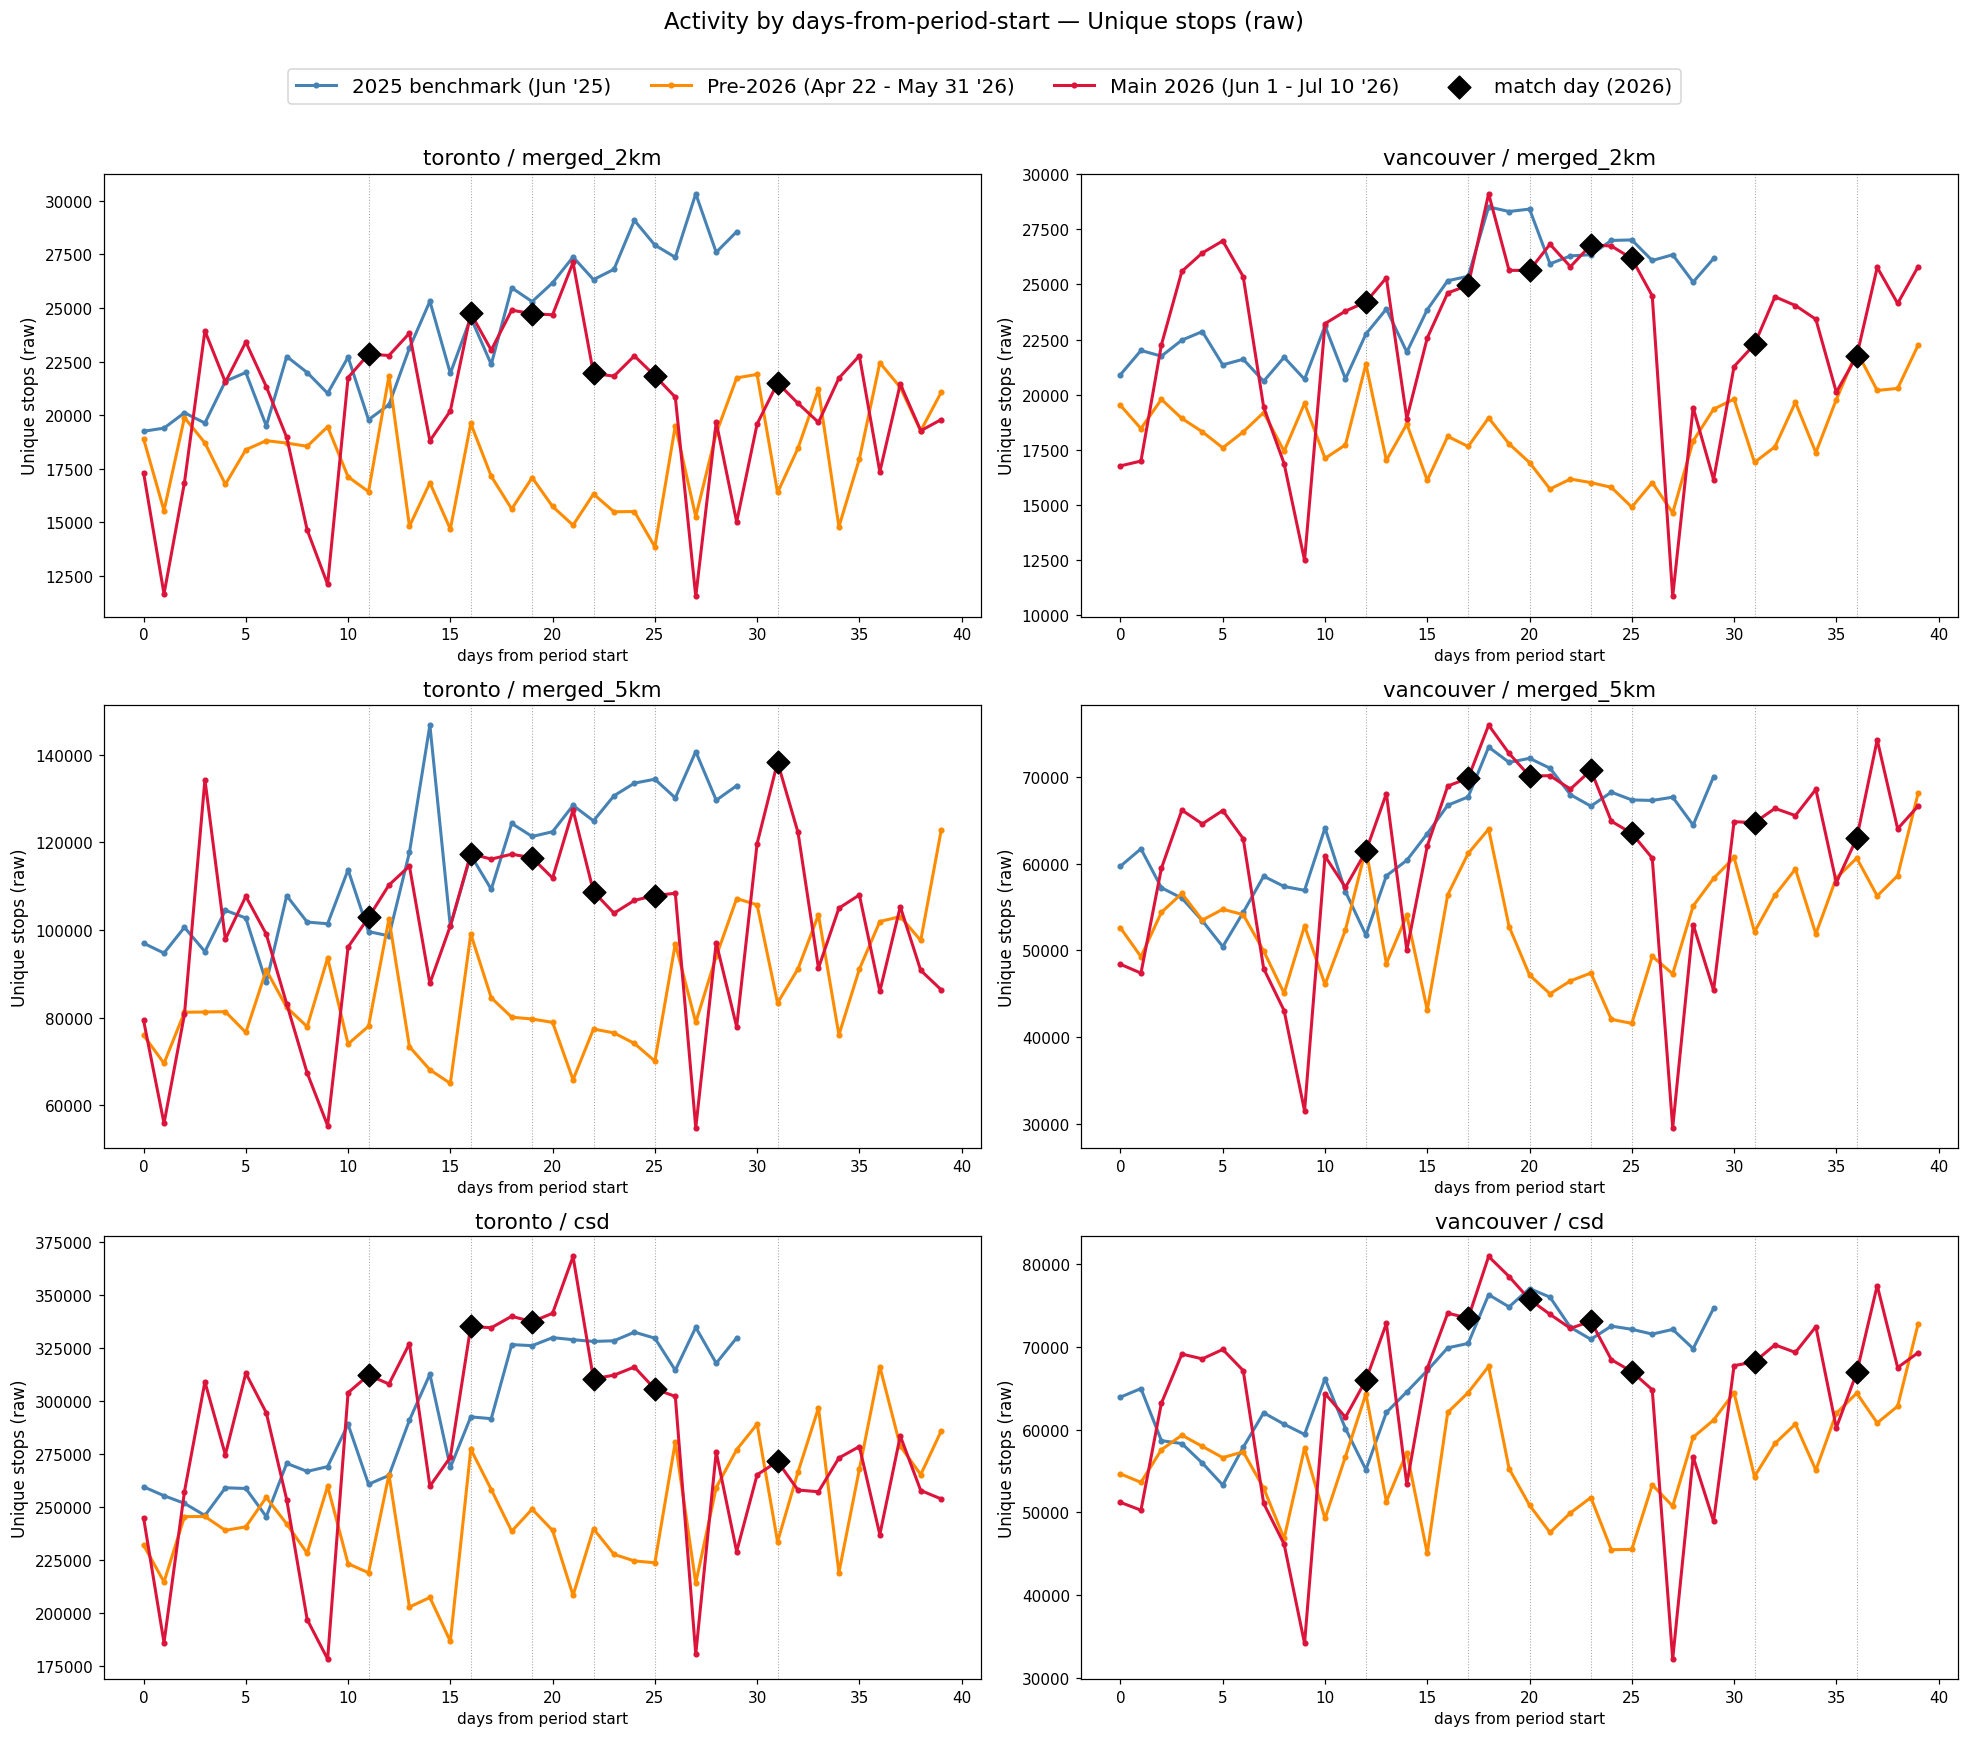

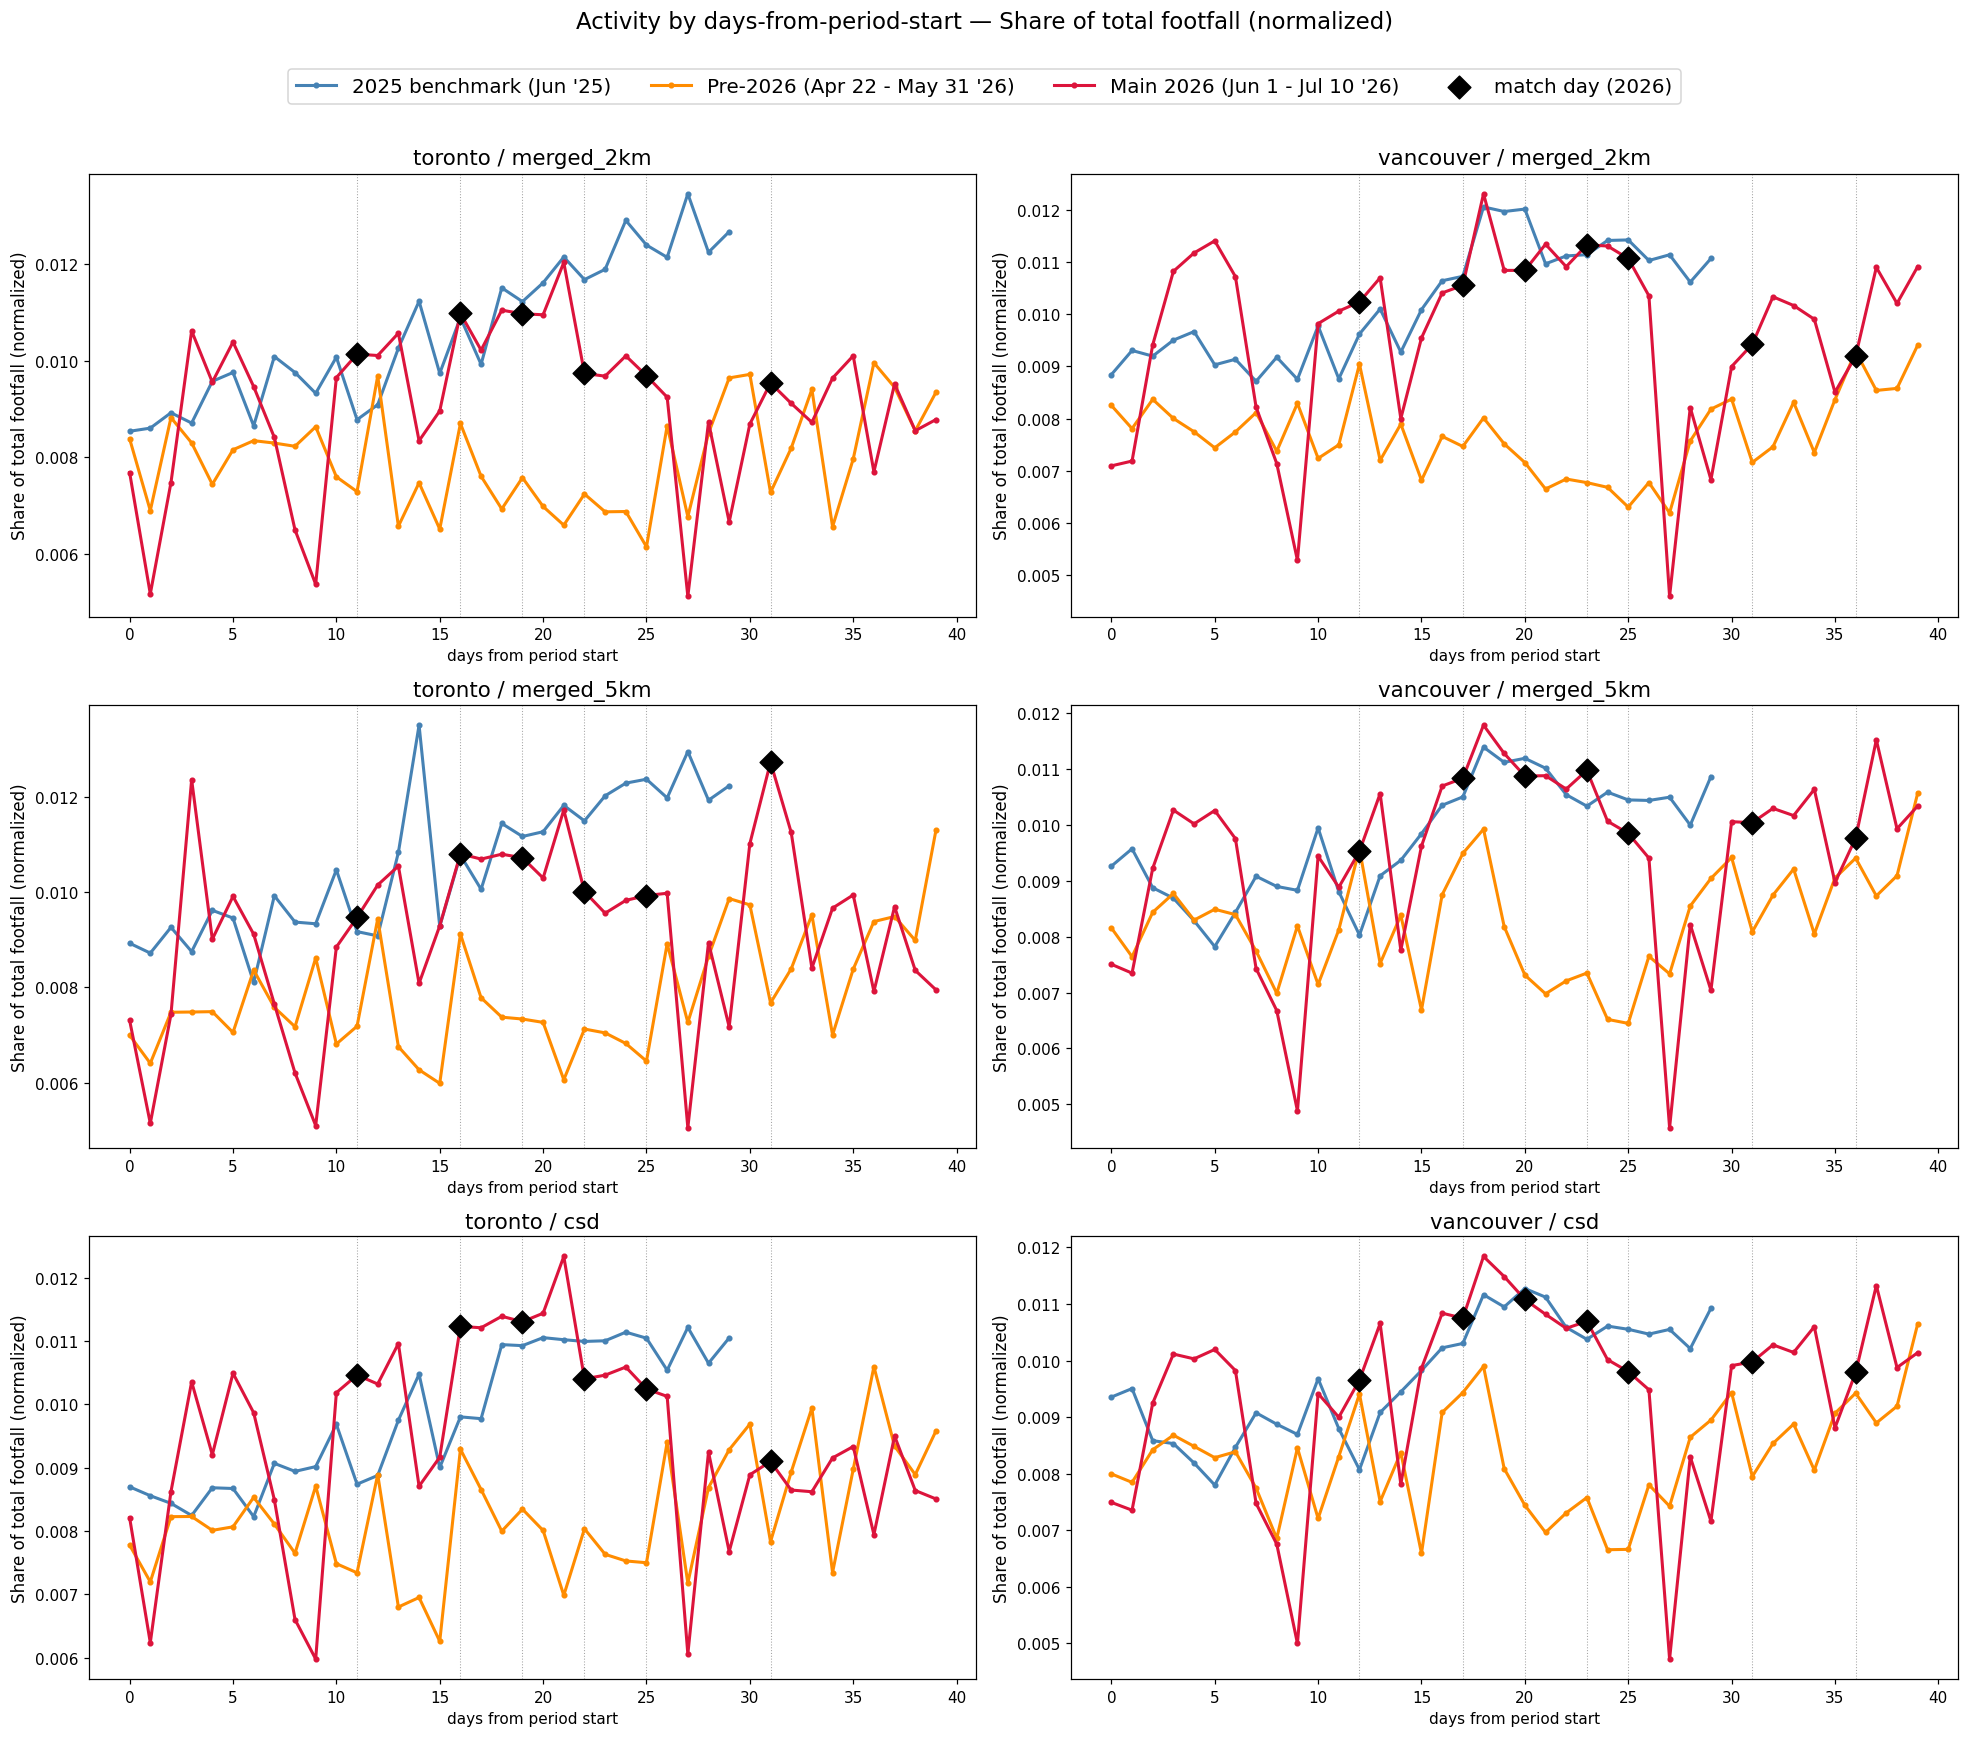

In [6]:
def plot_period_overlay(metric, metric_label):
    # sharey=False: Toronto's CSD is ~5x Vancouver's, so sharing a row's y-axis across cities
    # would flatten the smaller city's line into invisibility. Each panel gets its own scale;
    # the comparison that matters here is the 3 periods *within* a panel, not raw levels across cities.
    fig, axes = plt.subplots(len(LEVEL_ORDER), len(CITIES), figsize=(9 * len(CITIES), 5 * len(LEVEL_ORDER)), sharey=False)
    main_start, main_end = pd.to_datetime(MAIN_2026[0]), pd.to_datetime(MAIN_2026[1])

    for j, city in enumerate(CITIES):
        for i, level in enumerate(LEVEL_ORDER):
            ax = axes[i, j]
            sub = activity[(activity["city"] == city) & (activity["level"] == level)]

            for label, window, color in PERIOD_WINDOWS:
                start, end = pd.to_datetime(window[0]), pd.to_datetime(window[1])
                w = sub[(sub["DATE"] >= start) & (sub["DATE"] <= end)].sort_values("DATE")
                if w.empty:
                    continue
                day_offset = (w["DATE"] - start).dt.days
                ax.plot(day_offset, w[metric], lw=2.0, color=color, label=label, marker="o", markersize=3)

            main = sub[(sub["DATE"] >= main_start) & (sub["DATE"] <= main_end)].sort_values("DATE")
            is_match = main["DATE"].isin(MATCH_DAYS[city])
            match_offsets = (main.loc[is_match, "DATE"] - main_start).dt.days
            for d in match_offsets:
                ax.axvline(d, color="black", lw=0.7, ls=":", alpha=0.35, zorder=0)
            ax.scatter(match_offsets, main.loc[is_match, metric], color="black", zorder=5, s=110, marker="D", label="match day (2026)")

            ax.set_title(f"{city} / {level}", fontsize=14)
            ax.set_xlabel("days from period start", fontsize=10)
            ax.tick_params(labelsize=10)
            ax.set_ylabel(metric_label, fontsize=11)

    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="upper center", ncol=4, fontsize=13, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"Activity by days-from-period-start — {metric_label}", y=1.05, fontsize=15)
    fig.tight_layout()
    plt.show()

for metric, metric_label in tqdm(METRICS, desc="metric"):
    plot_period_overlay(metric, metric_label)


### 3a. Same story, as numbers

A compact numeric companion to the charts above: mean activity in each period, the % lift of Main 2026 over each benchmark, and — the most direct test — match days vs. non-match days *within* Main 2026 itself.


In [7]:
BENCH_LABEL, PRE_LABEL, MAIN_LABEL = [label for label, _, _ in PERIOD_WINDOWS]
main_start, main_end = pd.to_datetime(MAIN_2026[0]), pd.to_datetime(MAIN_2026[1])

rows = []
for metric, metric_label in METRICS:
    for city in CITIES:
        for level in LEVEL_ORDER:
            sub = activity[(activity["city"] == city) & (activity["level"] == level)]

            period_means = {}
            for label, window, _ in PERIOD_WINDOWS:
                start, end = pd.to_datetime(window[0]), pd.to_datetime(window[1])
                period_means[label] = sub[(sub["DATE"] >= start) & (sub["DATE"] <= end)][metric].mean()

            main = sub[(sub["DATE"] >= main_start) & (sub["DATE"] <= main_end)]
            is_match = main["DATE"].isin(MATCH_DAYS[city])
            match_mean = main.loc[is_match, metric].mean()
            nonmatch_mean = main.loc[~is_match, metric].mean()

            rows.append({
                "metric": metric_label, "city": city, "level": level,
                **{label: period_means[label] for label, _, _ in PERIOD_WINDOWS},
                "match_day_mean": match_mean, "non_match_day_mean": nonmatch_mean,
                "match_vs_nonmatch_pct": 100 * (match_mean / nonmatch_mean - 1),
                "main_vs_pre_pct": 100 * (period_means[MAIN_LABEL] / period_means[PRE_LABEL] - 1),
                "main_vs_2025_pct": 100 * (period_means[MAIN_LABEL] / period_means[BENCH_LABEL] - 1),
            })

summary = pd.DataFrame(rows).sort_values(["metric", "match_vs_nonmatch_pct"], ascending=[True, False])
summary[["metric", "city", "level", "match_vs_nonmatch_pct", "main_vs_pre_pct", "main_vs_2025_pct"]]


,metric,city,level,match_vs_nonmatch_pct,main_vs_pre_pct,main_vs_2025_pct
7,Share of total footfall (normalized),toronto,merged_5km,18.5179,17.2092,-13.0922
6,Share of total footfall (normalized),toronto,merged_2km,14.2043,14.3694,-14.0941
8,Share of total footfall (normalized),toronto,csd,13.5208,13.9415,-4.1796
10,Share of total footfall (normalized),vancouver,merged_5km,10.6802,14.6812,-2.9467
11,Share of total footfall (normalized),vancouver,csd,10.3508,14.4515,-2.5989
9,Share of total footfall (normalized),vancouver,merged_2km,9.2203,25.6629,-5.4188
1,Unique stops (raw),toronto,merged_5km,18.5179,17.2092,-13.0922
0,Unique stops (raw),toronto,merged_2km,14.2043,14.3694,-14.0941
2,Unique stops (raw),toronto,csd,13.5208,13.9415,-4.1796
4,Unique stops (raw),vancouver,merged_5km,10.6802,14.6812,-2.9467


## 4. Where is the activity coming from — proportional symbol maps

For the four requested sources (`toronto_csd`, `toronto_merged_2km`, `vancouver_csd`, `vancouver_merged_2km`), we take the **mean recomputed share across all match days** for each home region, at both scales:
- **Metro scale** (`metro_pct`) — the municipality-level breakdown within the home CMA (Toronto CSD, Mississauga, Vaughan, ... / Vancouver CSD, Burnaby, Surrey, ...).
- **NA-wide scale** (`na_pct`) — the home CMA, the **rest of the home province excluding that CMA** (its own point now, not folded away), other provinces, and the US.

Region locations come from real Statistics Canada boundary files in `data/final_geoms/` (CSD, CMA, and province polygons): we compute each region's true centroid, and for "rest of province" we take the actual province-minus-CMA polygon (via geometric difference) and centroid *that*. The same boundary polygons are drawn faintly in the background (municipality outlines at the metro scale; province + CMA outlines at the NA-wide scale, simplified for a clean line) so the symbols sit on an approximate map rather than a bare grid — no basemap tiles are available offline, so gridlines/axis ticks are dropped in favor of these real boundaries.

Circle **area** is proportional to mean share (the standard proportional-symbol convention — area, not radius, scales linearly with value).


In [8]:
def polygon_centroid_latlon(geom_series):
    """Centroid (lat, lon) of a (possibly multi-row) GeoSeries, computed in its own projected CRS."""
    merged = geom_series.union_all()
    pt = gpd.GeoSeries([merged.centroid], crs=geom_series.crs).to_crs(4326).iloc[0]
    return (pt.y, pt.x)

# Simplify tolerance (degrees, ~2km) for boundary *outlines only* - Ontario/Quebec province polygons carry
# 50k+ vertices at full resolution, way more detail than a faint background line needs.
BOUNDARY_SIMPLIFY_TOL = 0.02

REGION_COORDS = {}
CSD_BOUNDARIES = {}  # city -> GeoDataFrame of municipality outlines (EPSG:4326), for map backgrounds

# CSD (municipality) centroids + boundaries for both metro regions - dissolve by name first (a couple of
# municipalities, e.g. Langley, North Vancouver, are split into 2 polygons sharing one name)
for city, path in tqdm(CSD_SHAPEFILES.items(), desc="csd geometries"):
    gdf = gpd.read_file(path)
    for name, group in gdf.groupby("CSDNAME"):
        region = CSD_NAME_TO_REGION.get(name, name)
        REGION_COORDS[region] = polygon_centroid_latlon(group.geometry)
    dissolved = gdf.dissolve(by="CSDNAME", as_index=False).to_crs(4326)
    dissolved["geometry"] = dissolved.geometry.simplify(BOUNDARY_SIMPLIFY_TOL)
    CSD_BOUNDARIES[city] = dissolved

# CMA (metro) centroids + boundaries - all files confirmed in EPSG:3347, same as the province/CSD files below
cma_geoms = {}
CMA_BOUNDARIES = {}
for city, path in CMA_SHAPEFILES.items():
    gdf = gpd.read_file(path)
    cma_geoms[city] = gdf.geometry.iloc[0]
    REGION_COORDS[CMA_REGION_NAME[city]] = polygon_centroid_latlon(gdf.geometry)
    CMA_BOUNDARIES[city] = gpd.GeoSeries([gdf.geometry.iloc[0]], crs=gdf.crs).to_crs(4326).simplify(BOUNDARY_SIMPLIFY_TOL)

# Province/territory centroids + boundaries
province_geoms = {}
PROVINCE_BOUNDARIES = {}
for prov_name, abbr in tqdm(PROVINCE_SHAPEFILES.items(), desc="province geometries"):
    gdf = gpd.read_file(f"{GEOMS_DIR}/provinces_territories/{abbr}.shp")
    province_geoms[prov_name] = gdf
    REGION_COORDS[prov_name] = polygon_centroid_latlon(gdf.geometry)
    PROVINCE_BOUNDARIES[prov_name] = gdf.to_crs(4326).geometry.simplify(BOUNDARY_SIMPLIFY_TOL)

# "Rest of the home province" = province polygon minus its own CMA polygon, via real geometric difference
for city in CITIES:
    prov_gdf = province_geoms[HOME_PROVINCE[city]]
    rest_geom = prov_gdf.geometry.iloc[0].difference(cma_geoms[city])
    pt = gpd.GeoSeries([rest_geom.centroid], crs=prov_gdf.crs).to_crs(4326).iloc[0]
    REGION_COORDS[REST_OF_PROVINCE_REGION_NAME[city]] = (pt.y, pt.x)

# No Canadian boundary file covers the US - use the fixed approximation
REGION_COORDS["US"] = US_COORD

print(f"Built real-geometry coordinates for {len(REGION_COORDS)} regions")
pd.DataFrame(REGION_COORDS, index=["lat", "lon"]).T.sort_index().head(10)


csd geometries:   0%|          | 0/2 [00:00<?, ?it/s]

province geometries:   0%|          | 0/13 [00:00<?, ?it/s]

Built real-geometry coordinates for 80 regions


,lat,lon
Ajax,43.8690,-79.0276
Alberta,54.9360,-114.3868
Anmore,49.3440,-122.8498
Aurora,43.9962,-79.4473
BC - Metro Van,54.3254,-124.7101
Barnston Island 3,49.1883,-122.6953
Belcarra,49.3278,-122.8999
Bowen Island,49.3733,-123.3712
Bradford West Gwillimbury,44.1198,-79.6172
Brampton,43.7155,-79.7524


In [9]:
map_data = origin[origin["source"].isin(MAP_SOURCES)]

# Coverage check: make sure every region actually used at either scale now has a real-geometry coordinate
used_regions = set(map_data.loc[map_data["metro_pct"].notna() | map_data["na_pct"].notna(), "REGION"].unique())
missing = used_regions - set(REGION_COORDS)
print("Regions missing coordinates:", missing if missing else "none")
assert not missing, f"Add coordinates for: {missing}"

mean_pct = (
    map_data.melt(id_vars=["source", "city", "REGION"], value_vars=["metro_pct", "na_pct"],
                  var_name="scale", value_name="pct")
    .dropna(subset=["pct"])
    .groupby(["source", "city", "scale", "REGION"])["pct"].mean()
    .reset_index()
)
mean_pct.head(8)


Regions missing coordinates: none


,source,city,scale,REGION,pct
0,toronto_csd,toronto,metro_pct,Ajax,0.0038
1,toronto_csd,toronto,metro_pct,Aurora,0.0013
2,toronto_csd,toronto,metro_pct,Bradford West Gwillimbury,0.0009
3,toronto_csd,toronto,metro_pct,Brampton,0.0134
4,toronto_csd,toronto,metro_pct,Burlington,0.0018
5,toronto_csd,toronto,metro_pct,Caledon,0.0015
6,toronto_csd,toronto,metro_pct,East Gwillimbury,0.0006
7,toronto_csd,toronto,metro_pct,Georgina,0.0007


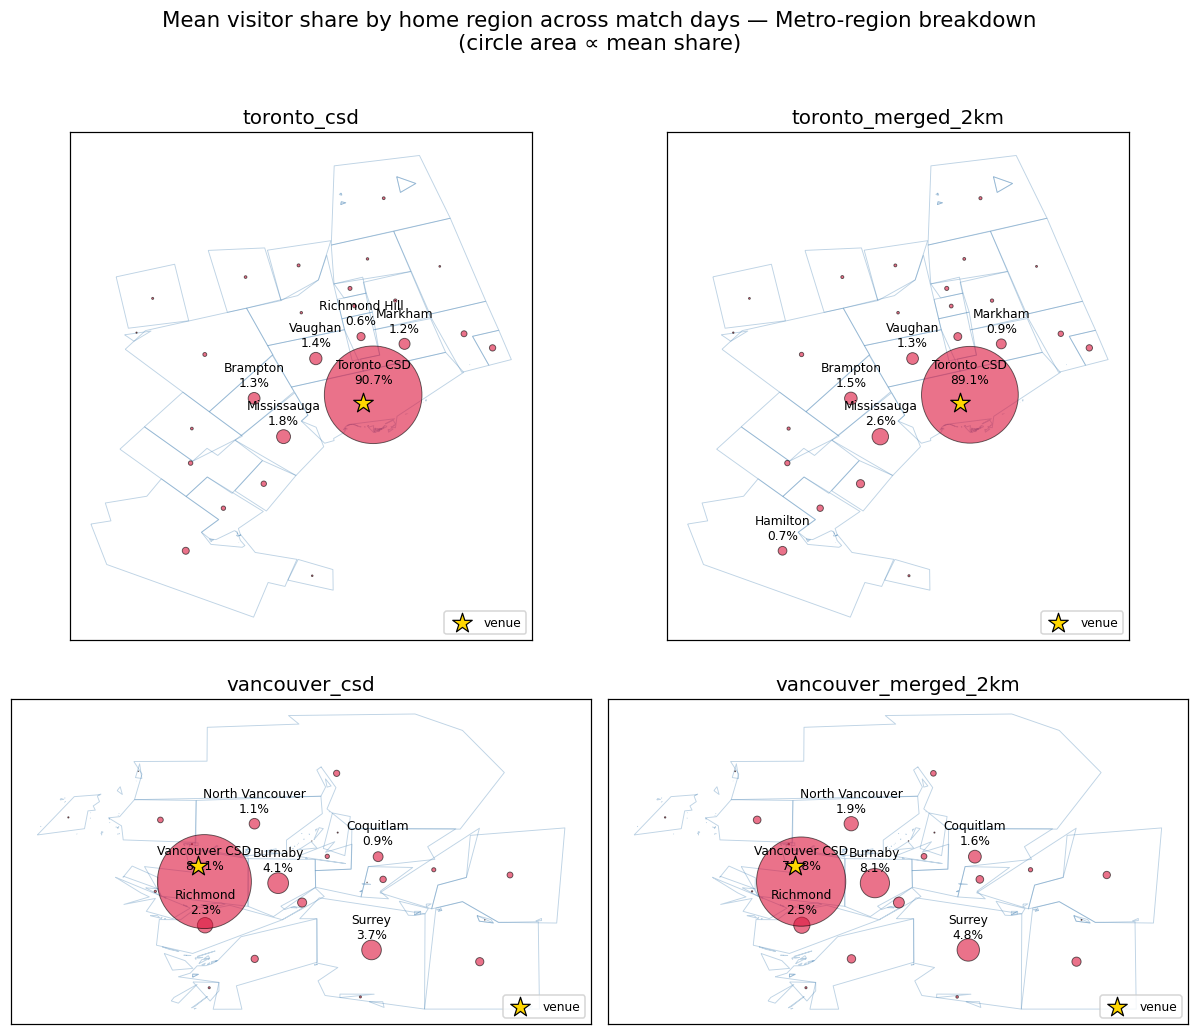

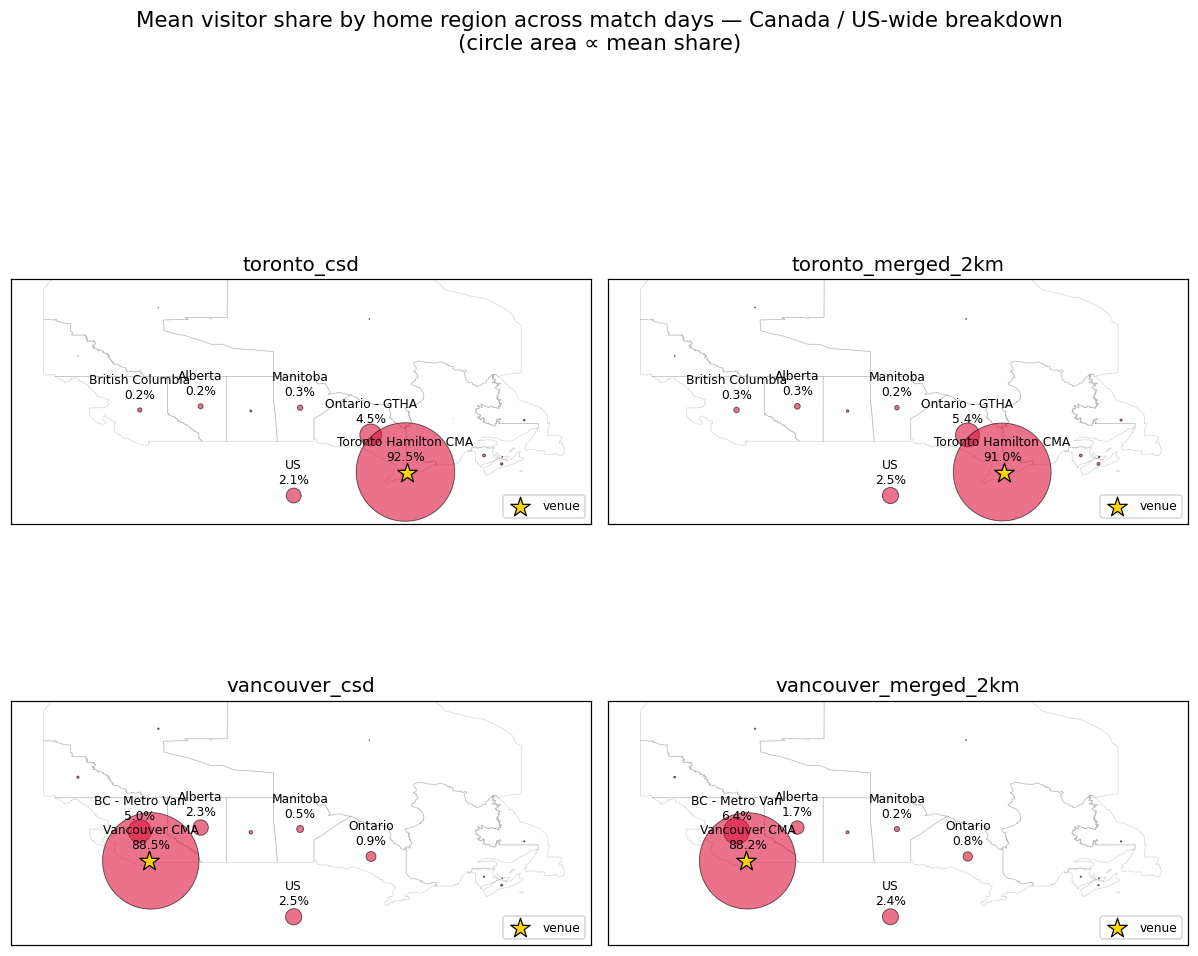

In [10]:
def plot_symbol_map(scale, scale_label, size_scale, n_labels=6):
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, source in zip(axes.flat, MAP_SOURCES):
        city = source.split("_")[0]

        # Faint boundary backdrop: municipality outlines for the metro scale, province + CMA outlines
        # for the NA-wide scale (so "rest of province" and other-province dots have visual context).
        if scale == "metro_pct":
            CSD_BOUNDARIES[city].boundary.plot(ax=ax, color="steelblue", linewidth=0.6, alpha=0.35, zorder=1)
        else:
            for prov_geom in PROVINCE_BOUNDARIES.values():
                prov_geom.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.3, zorder=1)
            CMA_BOUNDARIES[city].boundary.plot(ax=ax, color="steelblue", linewidth=0.9, alpha=0.6, zorder=2)

        d = mean_pct[(mean_pct["source"] == source) & (mean_pct["scale"] == scale)].copy()
        d = d[d["REGION"].isin(REGION_COORDS)]
        d["lat"] = d["REGION"].map(lambda r: REGION_COORDS[r][0])
        d["lon"] = d["REGION"].map(lambda r: REGION_COORDS[r][1])

        ax.scatter(d["lon"], d["lat"], s=d["pct"] * size_scale, alpha=0.6,
                   color="crimson", edgecolor="black", linewidth=0.6, zorder=3)

        clat, clon = CITY_CENTER[city]
        ax.scatter([clon], [clat], marker="*", s=180, color="gold", edgecolor="black", linewidth=0.8, zorder=5, label="venue")

        for _, r in d.nlargest(n_labels, "pct").iterrows():
            ax.annotate(f"{r['REGION']}\n{r['pct'] * 100:.1f}%", (r["lon"], r["lat"]), fontsize=8,
                        ha="center", va="bottom", xytext=(0, 6), textcoords="offset points")

        if scale != "metro_pct":
            # Province/CMA boundary polygons extend far past the relevant area (e.g. Yukon/Nunavut),
            # which would otherwise leave mostly dead space - crop to where the symbols actually are.
            # (Not needed for the metro scale: the municipality boundaries already bound a sensible extent.)
            lon_pad = max((d["lon"].max() - d["lon"].min()) * 0.15, 1.0)
            lat_pad = max((d["lat"].max() - d["lat"].min()) * 0.15, 0.5)
            ax.set_xlim(d["lon"].min() - lon_pad, d["lon"].max() + lon_pad)
            ax.set_ylim(d["lat"].min() - lat_pad, d["lat"].max() + lat_pad)

        ax.set_title(source, fontsize=13)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_aspect("equal")
        ax.legend(loc="lower right", fontsize=8)

    fig.suptitle(f"Mean visitor share by home region across match days — {scale_label}\n(circle area ∝ mean share)",
                 fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

plot_symbol_map("metro_pct", "Metro-region breakdown", size_scale=4500)
plot_symbol_map("na_pct", "Canada / US-wide breakdown", size_scale=4500)


## 5. Do those origins shift match day to match day?

The maps above collapse all match days into one mean snapshot. Here we keep the match-day axis: for each source, we track the top regions by mean share as separate lines across every match day (remaining regions collapsed into "Other") to see whether the mix is stable throughout the tournament or drifts (e.g. a knockout-round game drawing a more national/international crowd than an early group game).


scale:   0%|          | 0/2 [00:00<?, ?it/s]

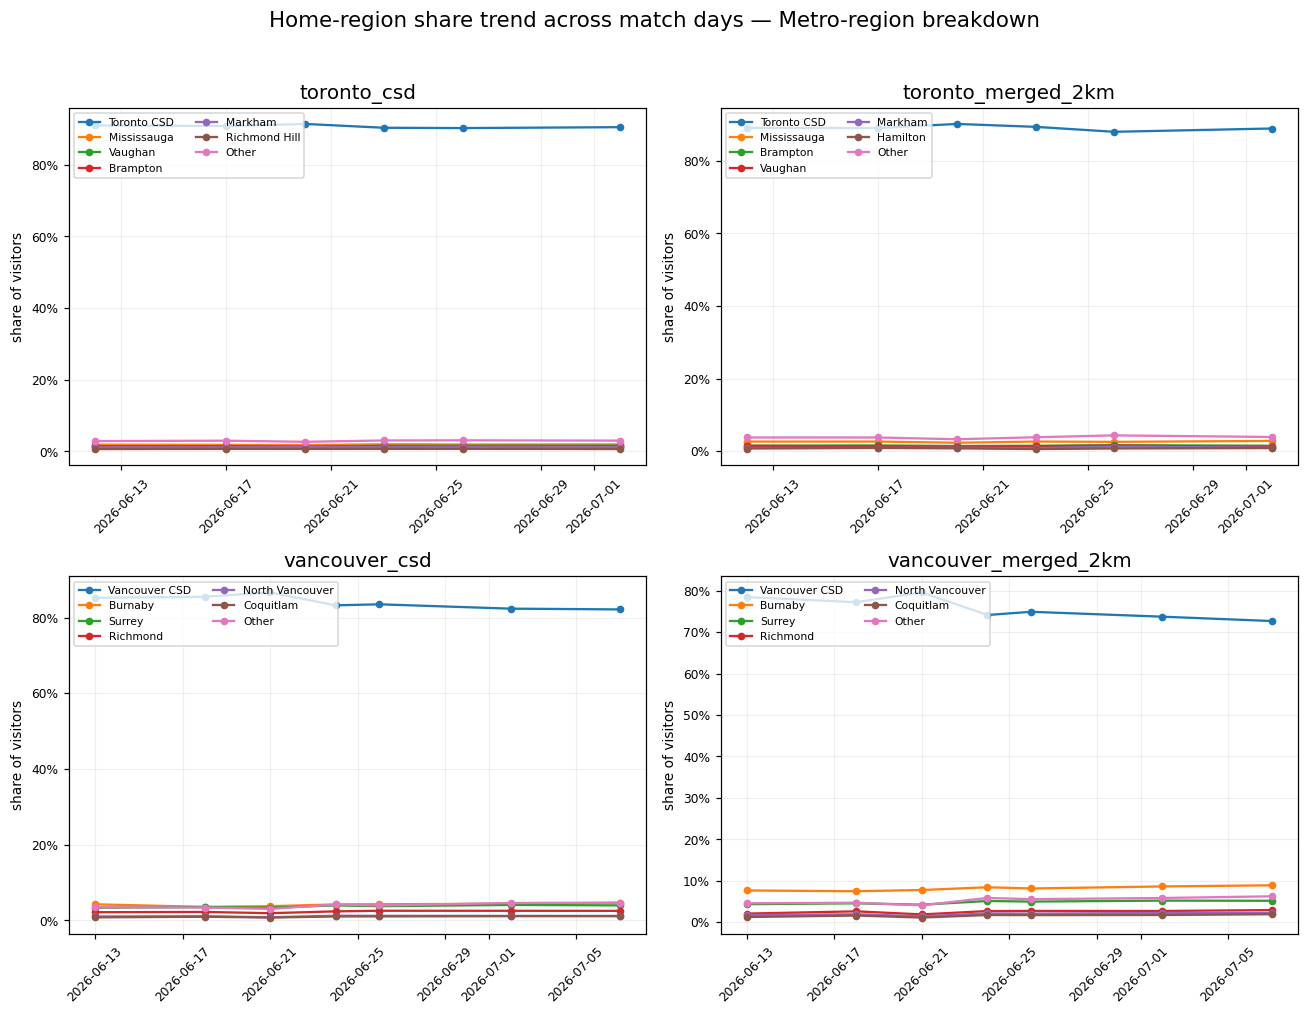

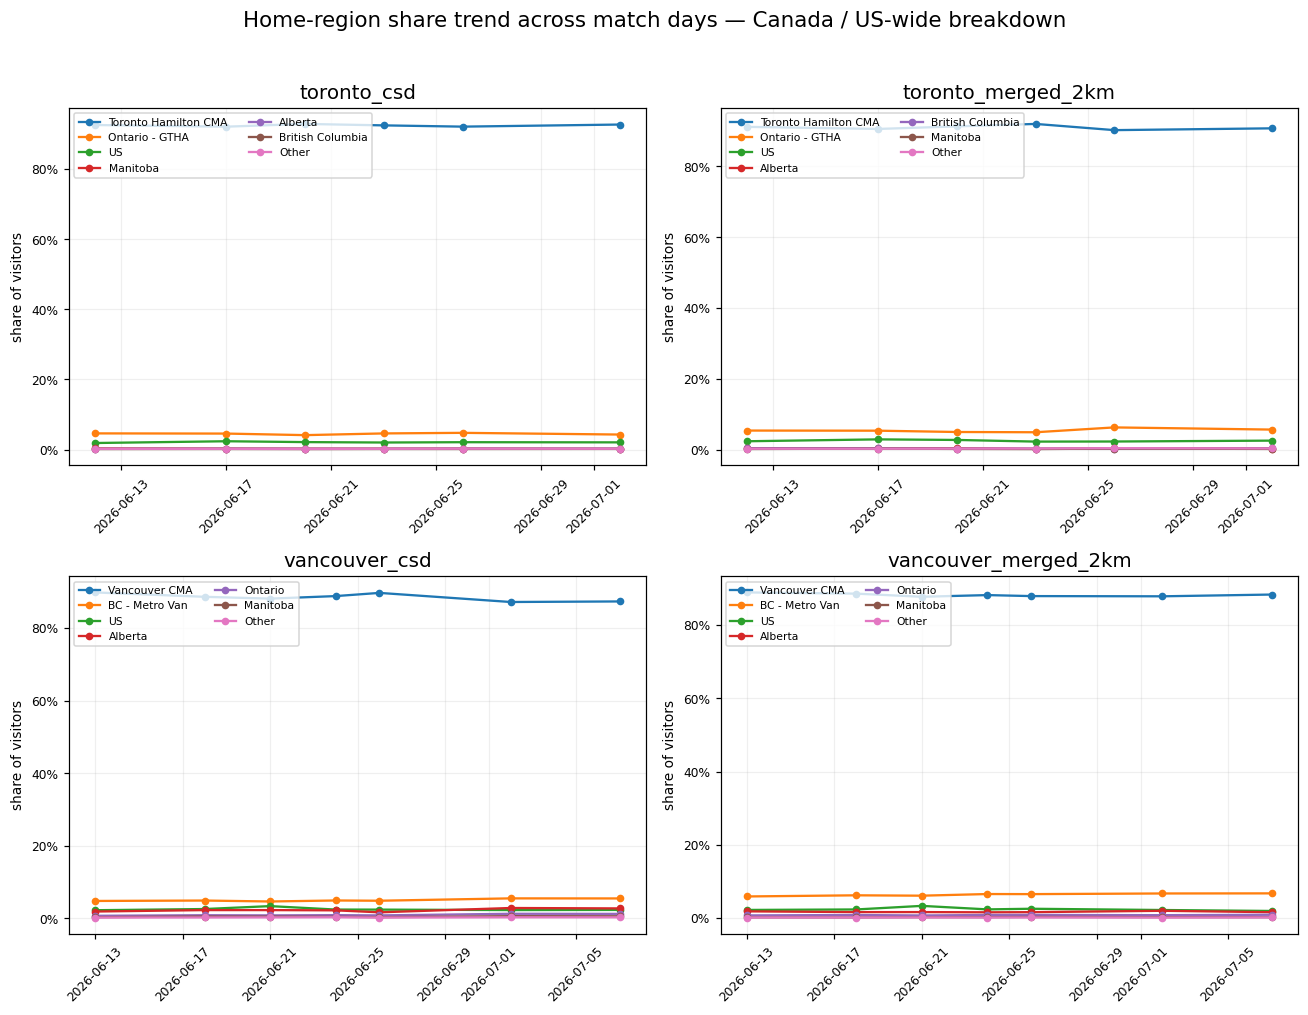

In [11]:
def plot_component_trends(scale, scale_label, n_top=6):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
    for ax, source in zip(axes.flat, MAP_SOURCES):
        d = origin[origin["source"] == source]
        d = d[d[scale].notna()][["DATE", "REGION", scale]].rename(columns={scale: "pct"})

        top_regions = d.groupby("REGION")["pct"].mean().nlargest(n_top).index.tolist()
        d = d.copy()
        d["group"] = np.where(d["REGION"].isin(top_regions), d["REGION"], "Other")
        grouped = d.groupby(["DATE", "group"])["pct"].sum().reset_index()

        pivot = grouped.pivot(index="DATE", columns="group", values="pct").sort_index()
        col_order = top_regions + (["Other"] if "Other" in pivot.columns else [])
        pivot = pivot[[c for c in col_order if c in pivot.columns]]

        for col in pivot.columns:
            ax.plot(pivot.index, pivot[col], marker="o", markersize=4, label=col)

        ax.set_title(source, fontsize=13)
        ax.set_ylabel("share of visitors", fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(fontsize=7, loc="upper left", ncol=2)
        ax.grid(alpha=0.2)

    fig.suptitle(f"Home-region share trend across match days — {scale_label}", fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

for scale, scale_label in tqdm([("metro_pct", "Metro-region breakdown"), ("na_pct", "Canada / US-wide breakdown")], desc="scale"):
    plot_component_trends(scale, scale_label)


## 6. Takeaways

**How much activity:**
- **Match days vs. non-match days within Main 2026 is the cleanest, most consistent signal.** Every city/geometry combination shows a positive lift (roughly +9% to +19%), and — notably — the raw and normalized metrics give *exactly identical* percentage lifts in every row. That's expected here: `normed_devices` is just `UNIQUESTOPS` divided by a constant (the geometry's own total footfall), so it's a pure linear rescaling and can never change a relative comparison. Unlike the device-panel normalization in the earlier notebook, this normalization doesn't add independent evidence against a "raw count" artifact — its real value shows up elsewhere (see below).
- **Main 2026 vs. the immediate pre-period (Apr 22 - May 31) is also consistently positive** (+14% to +26%), reinforcing that activity ramps up specifically around the tournament window, not just as a slow spring trend.
- **Main 2026 vs. the June 2025 benchmark is negative for every single row** (-3% to -14%) — the opposite direction from the other two comparisons. So a naive "activity is up year-over-year" claim doesn't hold; the within-2026 comparisons (match vs. non-match, main vs. pre-period) are the ones that isolate a genuine World Cup effect, while the year-over-year comparison is confounded by whatever baseline shift happened between the two years.
- The **normalized share metric is genuinely useful for comparing across geometries of very different physical/population scale** — e.g. Toronto's CSD (~2.9M metro population) vs. Vancouver's CSD (~700K) sit on wildly different raw-count axes, but their normalized share-of-footfall values land in the same ~0.5%-1.3% range, which is what makes the faceted overlay chart legible for both cities at once.

**Where the activity comes from:**
- Both cities are **extremely locally concentrated**: the home CSD itself accounts for ~75-91% of all visitors at the metro scale, with the next-largest single municipality (Mississauga for Toronto, Burnaby for Vancouver) capturing only a few percent. Toronto is somewhat more concentrated than Vancouver (~85-91% vs. ~75-84% own-CSD share).
- At the Canada/US-wide scale, the home CMA dominates even more heavily (~88-93%), with the rest of the province a distant second (~5-8%) and the US typically the largest single "outside country" source (~2-3%) — larger than any individual other Canadian province.
- The origin mix is **stable across match days** — no individual match or knockout-round date shows a meaningfully different geographic mix from the others, at either scale. This means the "how far do fans travel" story doesn't need a match-by-match caveat — one mean snapshot per source is representative of the whole tournament, at least among the dates in this file.
- Widening the venue geometry from `csd` to `merged_2km` doesn't meaningfully change the geographic mix (the two Toronto sources, and the two Vancouver sources, look very similar) — the origin composition is more a property of who visits the city than of exactly how tightly the venue buffer is drawn.

**Caveats:**
- The origin file's `NAWidePct` column has a real bug for minor regions (documented in section 2a) — any downstream use of this file should recompute from `AdjHomeDevices` rather than trust it directly.
- The origin file's match-day list includes two later-round dates (2026-07-02 for both cities, plus 2026-07-07 for Vancouver) beyond the original group-stage schedule; these are included throughout as match days.
- `merged_5km` is loaded and explored for the activity comparisons in Section 3, but intentionally excluded from the origin maps/trend lines in Sections 4-5, per the four specified sources.
